In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Intoduction

Text is an important source of data for many online platforms. Users share opinions, feedback, and reactions through comments, and handling this content manually can be difficult at scale. Automatically categorising comments helps platforms moderate content, prioritise discussions, and apply appropriate internal handling policies efficiently.
In this project, the goal is to build a machine learning model that predicts the final category assigned to a comment using its text and associated features.
The dataset includes short text comments along with engagement signals such as upvotes and downvotes, emoticon indicators, and some other indicators to detect topic references.
This project is created as a multiclass classification task, where each comment belongs to one of four possible categories. The project is a complete machine learning workflow, including exploratory data analysis (EDA), model training, evaluation, and comparison of various models.
Several machine learning algorithms are to be explored and compared to identify the most effective approach.

# Obejctive

The goal of this project is to build a machine learning model that can read a comment and correctly predict which category it belongs to, using the text and other related information.

# Datast

The dataset contains a collection of comments along with their associated features. Each comment is assigned a final category, which is the target variable to be predicted. The dataset includes textual data as well as additional attributes that help in understanding and classifying the comments.

# Exploratory Data Analysis (EDA)

In [17]:
# Load datasets
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (198000, 15)
Test Shape: (102000, 14)


In [18]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [19]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [20]:
test.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment'],
      dtype='object')

Exploratory data analysis is carried out to explore the dataset to understand its structure. The training data consists of 198,000 rows and 15 columns, while the test dataset contains 102,000 rows. As expected, the test data does not include the target label since it is used only for generating predictions.

In [21]:
#Basic information of the data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [22]:
#Number of missing values
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

The dataset was also checked for missing values. The columns race, religion, and gender contain a large number of missing entries, while the comment column has only one missing value. Other features do not contain missing values.

In [23]:
train.duplicated(subset="comment").sum()

np.int64(157)

In [24]:
#Checking for inconsistancey in duplicates labeling
train.groupby("comment")["label"].nunique().value_counts()

label
1    197837
2         5
Name: count, dtype: int64

In [25]:
# Find inconsistent comments
inconsistent = train.groupby("comment")["label"].nunique()
inconsistent = inconsistent[inconsistent > 1].index

# Remove them
train = train[~train["comment"].isin(inconsistent)]

#remove remaining duplicates
train = train.drop_duplicates(subset="comment")

A total of 157 duplicate entries were found.

Before removing duplicates, a consistency check was performed to ensure that duplicate comments did not have conflicting labels. A small number of inconsistencies were observed and removed to avoid introducing noise into the model.

Finally, the remaining duplicate entries were removed to reduce redundancy and prevent bias during

In [26]:
#Label distribution
train['label'].value_counts()

label
0    114065
2     62398
1     15913
3      5462
Name: count, dtype: int64

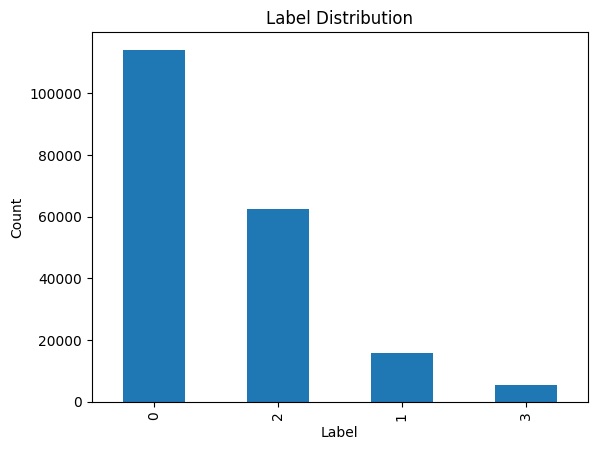

In [27]:
import matplotlib.pyplot as plt

train['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

The target variable (label) represents a multi-class classification problem with four classes (0, 1, 2, and 3). The distribution of labels shows a huge class imbalance, with class 0 having the highest number of samples and class 3 having the fewest. This imbalance may affect model performance and needs to be considered during model training.

In [28]:
#Comment length measuring
train['comment_length'] = train['comment'].astype(str).apply(len)
train['comment_length'].describe()

count    197838.000000
mean        303.116449
std         266.419183
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

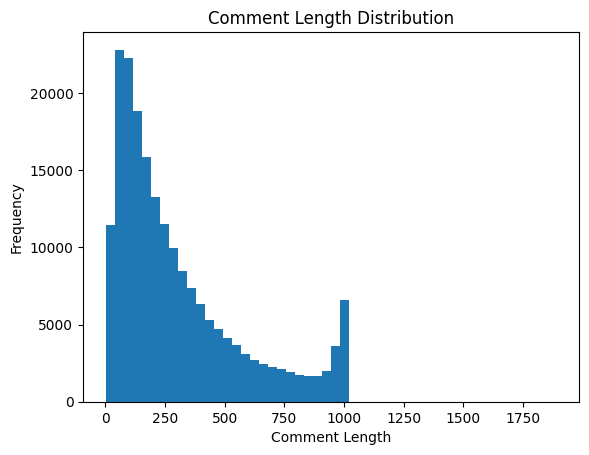

In [29]:
plt.hist(train['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

Additionally, the length of comments was analysed. Comment length varies widely, ranging from very short texts to longer, detailed comments. The average comment length is around 303 characters, indicating diversity in text size across the dataset.

Overall, the EDA helped identify class imbalance and missing values, which will be addressed during preprocessing and model development.

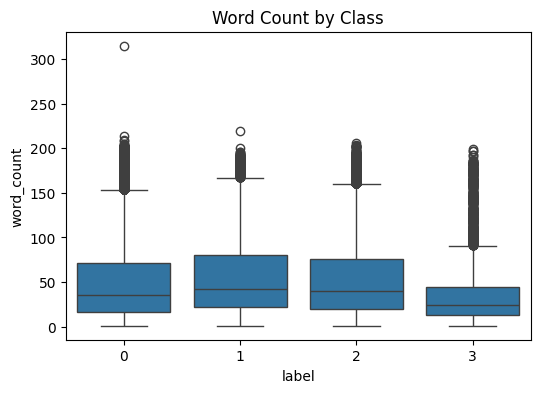

In [30]:
#Countinf word count in the comment variable
train["word_count"] = train["comment"].astype(str).apply(lambda x: len(x.split()))

import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(x=train["label"], y=train["word_count"])
plt.title("Word Count by Class")
plt.show()

The boxplot shows the distribution of word counts for each class label. It can be observed that most comments across all classes have relatively low to moderate word counts, with medians around a similar range. However, there are several outliers with very high word counts, indicating the presence of long comments in the dataset.

Overall, the distribution of word counts appears somewhat similar across classes, suggesting that text length alone may not strongly differentiate between classes.


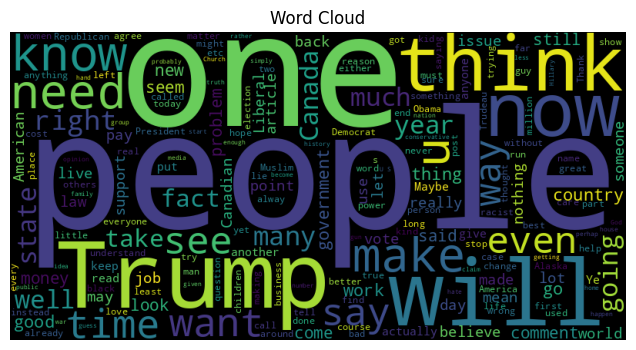

In [31]:
from wordcloud import WordCloud

text = " ".join(train["comment"].astype(str))

wc = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

The word cloud represents the most frequently occurring words in the dataset, where larger words indicate higher frequency. It can be observed that common terms such as “people”, “one”, and “know” appear prominently, suggesting that the dataset contains general conversational language. While this visualization provides an overview of frequently used words, it does not capture contextual importance, and hence more advanced techniques like TF-IDF are used for modeling.

# Dummy Submission

In [32]:
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

X_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

X = df.drop("label",axis =1)
y = df["label"]

from sklearn.dummy import DummyClassifier

model = DummyClassifier().fit(X,y)
y_pred = model.predict(X_test)

submission = pd.DataFrame({"ID": range(1,X_test.shape[0] + 1),
                            "label": y_pred})
submission.to_csv('submission.csv', index = False)

# Model 1 - Logistic Regression

****Data Preprocessing for Model 1****

In [33]:
# Importing Libraries
import re                                                            #for Text cleaning
from sklearn.model_selection import train_test_split                 #for  train validation split
from sklearn.feature_extraction.text import TfidfVectorizer          #for giving numerical values to comments
from sklearn.linear_model import LogisticRegression                  #logistic Regression
from sklearn.metrics import accuracy_score, classification_report    #for Evaluating the model

In [34]:
#creating a copy of the train dataset for the process
data = train.copy()

In [35]:
#droping the one missing value from the comment column
data = data.dropna(subset = ['comment'])

In [36]:
#dropping highly missiong columns (145k missing values each)
data = data.dropna(subset = ['race','religion','gender'])

In [38]:
#text cleaning

def clean_text(text):
    text = text.lower()                    #converting into lowercase
    text = re.sub(r'http\S+','',text)      #removing urls from the comments 
    text = re.sub(r'[^a-zA-Z\s]','',text)  #removing special characters,imojis,punctuations,numbers etc
    text = re.sub(r'\s+',' ',text).strip() #removing speces from beginning and end,also multiple spaces
    return text

#applying cleaning function to each comment
data['comment'] = data['comment'].astype(str).apply(clean_text)
    

In [39]:
#defining target and features
X = data['comment']
y = data['label']

In [40]:
#splitting the data into training(80%) and validation set (20%)

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, random_state =42, stratify = y)

In [41]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))

label
0    0.449911
2    0.277554
1    0.251267
3    0.021268
Name: proportion, dtype: float64
label
0    0.449900
2    0.277572
1    0.251308
3    0.021220
Name: proportion, dtype: float64


After applying stratified train validation split, the class proportions in both training and validation sets remain nearly identical. This ensures that the model is evaluated on a representative subset of the data.

In [42]:
#creating a TF-IDF object with keeping most important 5000 words
vectorizer = TfidfVectorizer(max_features= 5000)   

#converting comments into numerical values
X_train_vec = vectorizer.fit_transform(X_train)

#validationg the tarined model with validating data
X_val_vec = vectorizer.transform(X_val)


The comments were converted into numbers using TF-IDF so that the model can understand them. The transformation was learned from the training data and then applied to the validation data. Only the top 5000 important words were used as features.

****Logistic Regression****

In [43]:
#Creating a logistic regression function
log_model = LogisticRegression(max_iter = 1000,class_weight='balanced')

#Fitting the model into trainiing data
log_model.fit(X_train_vec,y_train)

#predicting on validation set
y_pred = log_model.predict(X_val_vec)

In [44]:
#Evaluating the model
print("Validation Accuracy : ", accuracy_score(y_val, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_val,y_pred))

Validation Accuracy :  0.6941669045579979

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      4728
           1       0.73      0.72      0.73      2641
           2       0.66      0.65      0.65      2917
           3       0.23      0.61      0.33       223

    accuracy                           0.69     10509
   macro avg       0.59      0.67      0.61     10509
weighted avg       0.71      0.69      0.70     10509



The Logistic Regression model achieved about 70% accuracy on the validation data. It performed well on the larger classes but had lower precision for the smallest class (label 3). However, the model was still able to identify many samples from the minority class because balanced class weights were used.

****Transforming the Model-1 into fulldata****

In [45]:
# Fit vectorizer on full training comments

X_full_vec = vectorizer.fit_transform(data['comment'])

#training logistic regression on full data

log_model.fit(X_full_vec, data['label'])

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Create a copy of the test data so that the raw data reamins still
test_data = test.copy()

# Applying the same text cleaning used for training data
test_data['comment'] = test_data['comment'].astype(str).apply(clean_text)

# Transform test comments using trained vectorizer
X_test_vec = vectorizer.transform(test_data['comment'])

#Predicting on test data
test_predictions = log_model.predict(X_test_vec)

In [ ]:
#Creaating Submission file
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission = sample.copy()
submission["label"] = test_predictions
submission.to_csv("submission.csv", index=False)

After evaluating Model-1 using an 80–20 validation split, the Logistic Regression model was retrained on the full training dataset to maximize learning before generating final predictions. The trained model was then applied to the unseen test data, and predictions were submitted to Kaggle.

The leaderboard score for Model-1 was approximately 0.63. While the model performed reasonably well on majority classes, it struggled with minority class prediction and showed limitations due to its linear nature and reliance solely on textual features. This motivated the development of improved text representations and stronger classifiers in subsequent models.

# Model 2 - Linear SVC 

****Improved TF-IDF Model****

In [46]:
#Importing Libraries
import re                                                           #for cleaning text
from sklearn.model_selection import train_test_split                #for training validation split
from sklearn.pipeline import Pipeline                               #for creating the pipeline
from sklearn.feature_extraction.text import TfidfVectorizer         #for giving numerical values to text data       
from sklearn.svm import LinearSVC                                   #importing linear svc model
from sklearn.metrics import accuracy_score, classification_report   #for evaluation of the model


****Data Preprocessing for model 2****

In [47]:
# Creating another copy for model 2
data2 = train.copy()

#Dropping only the single missing comment row
data2 = data2.dropna(subset = ['comment'])

#Dropping highly missing columns
data2 = data2.drop(columns = ['race','religion','gender'])

Removed columns with excessive missing values instead of dropping rows. This preserves the full dataset size and improves model learning capability than the last model

In [48]:
#Text cleaning not too much

def clean_text_v2(text):
    text = text.lower()                       #converting into lowercase
    text = re.sub(r'http\S+', '', text)       #removing URLs
    text = re.sub(r'\s+', ' ', text).strip()  #removing extra spaces
    return text

data2['comment'] = data2['comment'].astype(str).apply(clean_text_v2)

The text was cleaned minimally to remove URLs and extra spaces while keeping the punctuation and other useful signals rathat than the model 1.

In [50]:
#Defining features and tragets
X2 = data2['comment']
y2 = data2['label']

In [51]:
#stratified training and validation spliting of the data

X2_train, X2_val, y2_train, y2_val = train_test_split( X2, y2, test_size=0.2, random_state = 42, stratify = y2)

Since tha dataset is imbalaced, stratified split ensures that the class distribution remains similar in both training and validation datasets

In [52]:
# Model - 2 Alternative Implementation Using Pipeline
# This section demonstrates how preprocessing and modeling
# can be combined into a single workflow using sklearn Pipeline.
# The main model implementation used later in the notebook
# still uses manual TF-IDF vectorization.

pipeline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,    #selecting larger vocabulary (best 20k words)
        ngram_range=(1,2),     #unigrams + bigrams
        min_df=3,              #ignoring rare words
        max_df=0.95,           #ignoring overly common words
        sublinear_tf=True      #improve weighting
    )),
    ("classifier", LinearSVC(
        C=1.5,
        class_weight="balanced"
    ))
])

# Train pipeline
pipeline_model.fit(X2_train, y2_train)

# Prediction
pipeline_pred = pipeline_model.predict(X2_val)

print("Pipeline Model Accuracy:", accuracy_score(y2_val, pipeline_pred))

Pipeline Model Accuracy: 0.7728467448443186


In [53]:
# Storng TF - IDF vactorization (Manuel version)

vectorizer2 = TfidfVectorizer(
    max_features = 20000,              #selecting larger vocabulary (best 20k words)
    ngram_range = (1,2),               #unigrams + bigrams
    min_df = 3,                        #ignoring rare words
    max_df = 0.95,                     #ignoring overly common words
    sublinear_tf = True                #improve weighting
)

#fit the tf-idf value on the training data
X2_train_vec = vectorizer2.fit_transform(X2_train)

#transform the tf-idf values on validation data
X2_val_vec = vectorizer2.transform(X2_val)

TF-IDF converts text into numerical vectors.
Using 20,000 features and bigrams allows the model to capture both single words and meaningful word pairs, improving representation.

****Linear SVC****

In [54]:
# Training using Linear SVC

svm_model2 = LinearSVC(C = 1.5, class_weight = 'balanced')

svm_model2.fit(X2_train_vec, y2_train )

LinearSVC(C=1.5, class_weight='balanced')

LinearSVC is well-suited for high-dimensional sparse text data and balanced class weights help the model pay attention to minority classes.

In [55]:
#Prediction on validation data
y2_pred = svm_model2.predict(X2_val_vec)

print("Validation Accuracy:", accuracy_score(y2_val, y2_pred))
print("\nClassification Report:\n")
print(classification_report(y2_val, y2_pred))

Validation Accuracy: 0.7728467448443186

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.83     22813
           1       0.60      0.69      0.64      3183
           2       0.75      0.70      0.73     12480
           3       0.43      0.52      0.47      1092

    accuracy                           0.77     39568
   macro avg       0.65      0.69      0.67     39568
weighted avg       0.78      0.77      0.77     39568



****Model - 2 on Fulldata****

In [ ]:
# Create a fresh copy of original train data
data2_full = train.copy()

# Drop only missing comment
data2_full = data2_full.dropna(subset=['comment'])

# Drop highly missing columns (drop columns, not rows)
data2_full = data2_full.drop(columns=['race','religion','gender'])

# Apply same light cleaning
data2_full['comment'] = data2_full['comment'].astype(str).apply(clean_text_v2)


In [ ]:
#definign full features
X2_full = data2_full['comment']
y2_full = data2_full['label']

In [ ]:
# Fit the tf-idf value on FULL training comments
X2_full_vec = vectorizer2.fit_transform(X2_full)

In [ ]:
#Training SVM on full training data

#Defining the Linear SVC Model
svm_model2_full = LinearSVC(C=1.5,class_weight='balanced')

#Training the svc model on full training data
svm_model2_full.fit(X2_full_vec, y2_full)

In [ ]:
#Claening Test Data
#Create a copy so original test stays unchanged
test_data2 = test.copy()

#droping the same columns in test data as we did on training data
test_data2 = test_data2.drop(columns=['race','religion','gender'])

#Cleaning the comment section of test Data
test_data2['comment'] = test_data2['comment'].astype(str).apply(clean_text_v2)

In [ ]:
# Transform using the same vectorizor
X_test2_vec = vectorizer2.transform(test_data2['comment'])

#Predicting
test_predictions2 = svm_model2_full.predict(X_test2_vec)

In [ ]:
#Submission
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission2 = sample.copy()
submission2["label"] = test_predictions2

submission2.to_csv("submission.csv", index=False)

Model 2 was built using the full training dataset with improved text representation. Unlike Model 1, which used only 5,000 unigram features, this model used 20,000 TF-IDF features including both unigrams and bigrams. The inclusion of bigrams allowed the model to capture meaningful word pairs such as negations (e.g., “not good”), improving contextual understanding.

A Linear Support Vector Machine (LinearSVC) was used instead of Logistic Regression, as SVMs are generally more effective for high-dimensional sparse text data. Class weights were balanced to address the class imbalance present in the dataset.

The model achieved a validation accuracy of approximately 77%, representing a significant improvement over Model-1 (~70%). Performance improved notably for the minority classes, especially class 3, demonstrating that richer text representation and a stronger linear classifier enhanced predictive capability.

However, the Kaggle leaderboard score (~0.67) indicates a gap between validation and hidden test performance, suggesting possible distribution differences or the need for additional structured features. This motivates the development of a more advanced hybrid model in the next stage

# Model 3 - LightGBM

****Text + Structured Features****

In [56]:
# Importing Libraries
from sklearn.model_selection import train_test_split                #for training validation split
from sklearn.feature_extraction.text import TfidfVectorizer         #for giving numerical values to text data
from scipy.sparse import hstack                                     #for merging numerical and textual features
import lightgbm as lgb                                              # importing Light GBM Classifier
from sklearn.metrics import accuracy_score, classification_report   #for evaluating the model

# For Ploting
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [57]:
#Creating a copy of clean data
data3 = data2.copy()

****Feature Engineering****

In [58]:
# Creating additional numeric features
data3["comment_len"] = data3["comment"].str.len()
data3["word_count"] = data3["comment"].str.split().apply(len)
data3["vote_diff"] = data3["upvote"] - data3["downvote"]

Additional numerical features were created to capture structural patterns in the comments. Features such as comment length, word count, and vote difference may provide additional predictive power other than the textual content.

In [59]:
#Separating Textual and Numeric Features
X3_text = data3["comment"]
y3 = data3["label"]

numeric_cols = ["emoticon_1","emoticon_2","emoticon_3","upvote","downvote","vote_diff","if_1","if_2","disability","comment_len","word_count"]

X3_numeric = data3[numeric_cols]

These textual and numeric features will later be combined into a single model input.

In [60]:
#Spliting training and validation data fro both numeric and textual features

X3_text_train, X3_text_val, X3_num_train, X3_num_val, y3_train, y3_val = train_test_split(
    X3_text,
    X3_numeric,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

I split both text and numerical data together to ensure that all features and the target variable remain aligned for each observation. Since each row contains both text and numerical features, splitting them together guarantees that the corresponding text, numerical values, and labels belong to the same samples in both training and validation sets

In [61]:
#Vectorization for the texts

vectorizer3 = TfidfVectorizer(
    max_features=15000,      #selecting most 15k important words
    ngram_range=(1,2),       #unigrams + bigrams
    min_df=3,                #ignoring rarewords
    max_df=0.9,              #ignoring overly common words
    sublinear_tf=True        #improve weightage
)

X3_text_train_vec = vectorizer3.fit_transform(X3_text_train)
X3_text_val_vec = vectorizer3.transform(X3_text_val)

TF-IDF converts comments into 15,000 numerical features including both single words and bigrams.

In [64]:
# Converting numeric features to float
X3_num_train = X3_num_train.astype("float32")
X3_num_val = X3_num_val.astype("float32")

In [65]:
#Merging textual and numerical features

X3_train_final = hstack([X3_text_train_vec, X3_num_train])
X3_val_final = hstack([X3_text_val_vec, X3_num_val])

Textual and numeric features are merged into a single feature matrix so that the model can learn from both types simultaneously.

****LightGBM****

In [66]:
#Training LightGBM

# Creating the LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=800,        # Number of boosting trees to build
    learning_rate=0.05,      # Step size for updating model
    num_leaves=63,           # Maximum leaves per tree
    class_weight="balanced", # Adjust weights to handle class imbalance
    random_state=42          # Fix randomness for reproducibility
)

# Training (fit) the model on training data
lgb_model.fit(X3_train_final, y3_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 19.707781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1388903
[LightGBM] [Info] Number of data points in the train set: 158269, number of used features: 15011
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=800,
               num_leaves=63, random_state=42)

LightGBM is a gradient boosting tree algorithm that can model nonlinear relationships and interactions between features. It is particularly effective for large structured datasets.

In [67]:
#Evaluating the model

#Prediction on validation data
y3_pred = lgb_model.predict(X3_val_final)

print("Validation Accuracy:", accuracy_score(y3_val, y3_pred))
print("\nClassification Report:\n")
print(classification_report(y3_val, y3_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Validation Accuracy: 0.9100535786494137

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22813
           1       0.73      0.82      0.77      3183
           2       0.87      0.89      0.88     12480
           3       0.61      0.70      0.65      1092

    accuracy                           0.91     39568
   macro avg       0.80      0.84      0.82     39568
weighted avg       0.91      0.91      0.91     39568



Model-3 combines both textual features and structured numeric features. The comments were converted into TF-IDF vectors using 15,000 features with unigrams and bigrams. In addition to text, several numerical features such as upvotes, downvotes, emoticons, vote difference, comment length, and word count were included to provide additional context.

A LightGBM classifier was used because it can capture complex nonlinear relationships and interactions between text and numeric features. The model achieved a validation accuracy of approximately 91%, showing a significant improvement over the previous models. This indicates that combining structured signals with textual information greatly enhances predictive performance.

****Model 3 on Full Training Data****

In [ ]:
# Creating a working copy
data3_full = data2.copy()

# Creating numeric features
data3_full["comment_len"] = data3_full["comment"].str.len()
data3_full["word_count"] = data3_full["comment"].str.split().apply(len)
data3_full["vote_diff"] = data3_full["upvote"] - data3_full["downvote"]

In [ ]:
#Separating textual and numeric features
X3_text_full = data3_full["comment"]
y3_full = data3_full["label"]

numeric_cols = ["emoticon_1","emoticon_2","emoticon_3","upvote","downvote","vote_diff","if_1","if_2","disability","comment_len","word_count"]

X3_num_full = data3_full[numeric_cols].astype("float32")

In [ ]:
#Recreating vectorization on full training data

vectorizer3_full = TfidfVectorizer(
    max_features=15000,  #Selecting most important 15k words
    ngram_range=(1,2),   #unigrams + bigrams
    min_df=3,            #ignoting rare words
    max_df=0.9,          #ignoring overly common words
    sublinear_tf=True    #Improving weigtage
)

# Apllying the tf-idf values to full training data
X3_text_full_vec = vectorizer3_full.fit_transform(X3_text_full)

In [ ]:
#Combinig textual and numeric features

X3_full_final = hstack([X3_text_full_vec, X3_num_full])

In [ ]:
#Training LightGBM on fulldata

# Creating the LightGBM classifier
lgb_model_full = lgb.LGBMClassifier(
    n_estimators=600,            # Number of boosting trees to build
    learning_rate=0.05,          # Step size for updating model
    num_leaves=40,               # Maximum leaves per tree
    class_weight="balanced",     # Adjust weights to handle class imbalance
    random_state=42              # Fix randomness for reproducibility
)

# Training (fit) the model on full training data
lgb_model_full.fit(X3_full_final, y3_full)

In [ ]:
# Creating test copy
test_data3 = test.copy()

# Drop same columns
test_data3 = test_data3.drop(columns=["race","religion","gender"])

# Applying same cleaning
test_data3["comment"] = test_data3["comment"].astype(str).apply(clean_text_v2)

# Create numeric features on test data
test_data3["comment_len"] = test_data3["comment"].str.len()
test_data3["word_count"] = test_data3["comment"].str.split().apply(len)
test_data3["vote_diff"] = test_data3["upvote"] - test_data3["downvote"]

X3_test_text = test_data3["comment"]
X3_test_num = test_data3[numeric_cols].astype("float32")


In [ ]:
#Apllying TF-IDF values to full test data
X3_test_text_vec = vectorizer3_full.transform(X3_test_text)

#Combining test features
X3_test_final = hstack([X3_test_text_vec, X3_test_num])

#Predicting
test_predictions3 = lgb_model_full.predict(X3_test_final)

In [ ]:
#Saving for submission
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission3 = sample.copy()
submission3["label"] = test_predictions3

submission3.to_csv("submission.csv", index=False)

Model-3 combined textual features with structured numeric features such as vote difference, emoticons, and comment length. A LightGBM classifier was used to capture nonlinear relationships and feature interactions. This hybrid approach substantially improved performance and achieved a final Kaggle score of 0.805, successfully meeting the project objective.

****Confusion Matrix for Model 3****

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


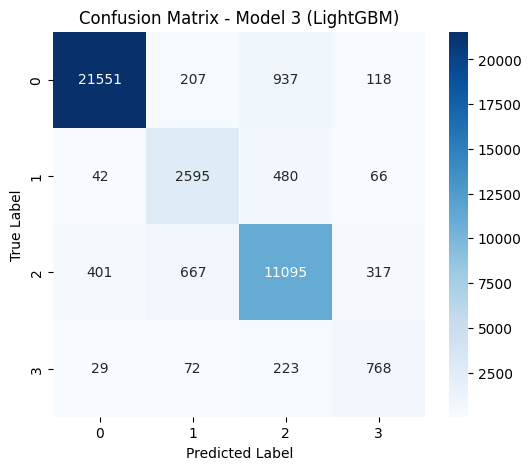

In [68]:
# Predict on validation set (using final validation data)
y_val_pred = lgb_model.predict(X3_val_final)

# Compute confusion matrix
cm = confusion_matrix(y3_val, y_val_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y3_val),
            yticklabels=np.unique(y3_val))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Model 3 (LightGBM)")
plt.show()

The confusion matrix shows that most predictions lie along the diagonal, indicating strong overall classification performance. Compared to Model-1, the prediction performance for Class 3 (the minority class) has significantly improved, demonstrating that the hybrid LightGBM model handles class imbalance more effectively. Some confusion is observed between Class 1 and Class 2, suggesting overlapping feature patterns between these categories.

****Feature Importance Diagram for Model 3****

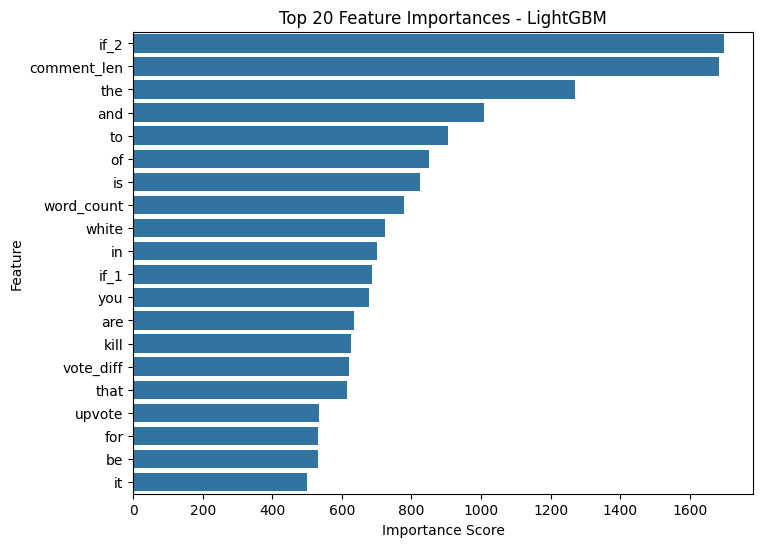

In [69]:
# Getting feature importance values
importances = lgb_model.feature_importances_

# Since we combined TF-IDF + numeric features,
# getting total feature names
tfidf_features = vectorizer3.get_feature_names_out()
all_features = list(tfidf_features) + numeric_cols

# Creating dataframe
feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
})

# Sorting by importance
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

# Ploting top 20 features
plt.figure(figsize=(8,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance_df.head(20)
)

plt.title("Top 20 Feature Importances - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that both structured and textual features contribute to the model’s predictions. Common words such as “the”, “to”, and “and” appear important because tree-based models use them as statistical split points across different classes, even if they are not semantically meaningful. Their frequent occurrence can help separate patterns between categories. Additionally, structured features like if_2, comment length, and vote difference play a major role, confirming that combining numeric and textual features improved the model’s performance.

# Hyperparameter Tuning for LightGBM

GridSearchCV was initially implemented, but due to the large dataset and high dimensional feature space, it was computationally expensive and it is taking more than 3 hours, Therefore, RandomizedSearchCV is used to efficiently explore different hyperparameter combinations.

In [ ]:
# Hyperparameter Tuning using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# Base model
lgb_base = lgb.LGBMClassifier(
    class_weight="balanced",
    random_state=42
)

# Parameter distributions
param_dist = {
    "n_estimators": [500, 600, 650],     # number of trees
    "num_leaves": [31, 40, 50],          # number of leaves - tree complexity
    "learning_rate": [0.05, 0.04]        # step size for learning
}

# Random search
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=4,                            # number of random combinations to try
    cv=2,                                # number of cross-validation folds 
    scoring="accuracy",                  # evaluation metric
    n_jobs=-1,                           # use all CPU cores for faster computation
    verbose=1,                           # display progress during training
    random_state=42
)

# Fit on training split
random_search.fit(X3_train_final, y3_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

In [ ]:
#Training full data using the best parameters
best_params = random_search.best_params_

lgb_model_tuned = lgb.LGBMClassifier(
    n_estimators=best_params["n_estimators"],
    num_leaves=best_params["num_leaves"],
    learning_rate=best_params["learning_rate"],
    class_weight="balanced",
    random_state=42
)

lgb_model_tuned.fit(X3_full_final, y3_full)

In [ ]:
#Prediction on full test data
test_predictions_tuned = lgb_model_tuned.predict(X3_test_final)

#Creating submission file
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission_tuned = sample.copy()
submission_tuned["label"] = test_predictions_tuned

submission_tuned.to_csv("submission.csv", index=False)

# Conclusion

In this project, three different models were developed to classify comments into four categories.

Model-1 used TF-IDF with Logistic Regression and served as a baseline model. It achieved moderate performance but struggled with minority class prediction.

Model-2 improved the text representation by increasing the TF-IDF feature size and including bigrams, and used a Linear SVM classifier. This significantly improved validation performance and demonstrated better handling of high-dimensional sparse text data.

Model-3 combined textual features with structured numeric features such as vote difference, emoticons, and comment length. A LightGBM classifier was used to capture nonlinear relationships and feature interactions. This hybrid approach substantially improved performance.

Further improvements were achieved through hyperparameter tuning, where different configurations of key parameters such as the number of estimators and number of leaves were explored to optimize model performance. The final tuned model **achieved a Kaggle score of 0.81078**, successfully meeting the project objective.

Overall, the results demonstrate that combining effective text representation, feature engineering, and a well-tuned boosting model leads to significantly better classification performance.